# 🔥 Transformer SOC Prediction — Google Colab GPU
**State of Charge prediction using Transformer Encoder**

Architecture:
- Multi-Head Self-Attention
- Positional Encoding
- Feed-Forward Blocks
- Regression Head

➡️ Runtime → Change runtime type → **T4 GPU** before running!

In [1]:
# ============================================================
# CELL 1 — Check GPU
# ============================================================
import torch
print('CUDA available:', torch.cuda.is_available())
print('GPU:', torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'None')
print('PyTorch version:', torch.__version__)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Using device:', device)

CUDA available: True
GPU: Tesla T4
PyTorch version: 2.10.0+cu128
Using device: cuda


In [2]:
# ============================================================
# CELL 2 — Import Libraries
# ============================================================
!pip install -q scikit-learn pandas numpy matplotlib seaborn scipy

import time
import copy
import math
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

torch.manual_seed(42)
np.random.seed(42)
print('All libraries loaded ')

All libraries loaded 


In [5]:
# ============================================================
# CELL 3 — Upload CSV
# ============================================================
from google.colab import files
uploaded = files.upload()
csv_name = list(uploaded.keys())[0]
print('Uploaded:', csv_name)

Saving Merged.csv to Merged.csv
Uploaded: Merged.csv


In [6]:
# ============================================================
# CELL 4 — Load & Parse Data
# ============================================================
df = pd.read_csv(csv_name)
df.columns = df.columns.str.strip()
print('Shape:', df.shape)
print('Columns:', df.columns.tolist())

def find_col(df, keyword):
    """Case-insensitive column finder"""
    matches = [c for c in df.columns if keyword.lower() in c.lower()]
    if not matches:
        raise ValueError(f'Column with keyword "{keyword}" not found. Available: {df.columns.tolist()}')
    return matches[0]

col_velocity    = find_col(df, 'Velocity')
col_elevation   = find_col(df, 'Elevation')
col_throttle    = find_col(df, 'Throttle')
col_torque      = find_col(df, 'MotorTorque')
col_accel       = find_col(df, 'LongitudinalAcceleration')
col_regen       = find_col(df, 'RegenerativeBraking')
col_voltage     = find_col(df, 'BatteryVoltage')
col_current     = find_col(df, 'BatteryCurrent')
col_batttemp    = find_col(df, 'BatteryTemperature')
col_ambtemp     = find_col(df, 'AmbientTemperature')
col_aircon      = find_col(df, 'AirConPower')
col_heater      = find_col(df, 'HeaterCurrent')
col_soc         = find_col(df, 'SoC')

print('\nMapped columns:')
for name, col in [('Velocity',col_velocity),('Voltage',col_voltage),('SOC',col_soc)]:
    print(f'  {name} → {col}')

Shape: (1048575, 27)
Columns: ['MergedTime', 'Time_s_', 'Velocity_km_h_', 'Elevation_m_', 'Throttle___', 'MotorTorque_Nm_', 'LongitudinalAcceleration_m_s_2_', 'RegenerativeBrakingSignal', 'BatteryVoltage_V_', 'BatteryCurrent_A_', 'BatteryTemperature__C_', 'max_BatteryTemperature__C_', 'SoC___', 'displayedSoC___', 'min_SoC___', 'max_SoC___', 'RequestedHeatingPower_W_', 'AirConPower_kW_', 'HeaterSignal', 'HeaterVoltage_V_', 'HeaterCurrent_A_', 'AmbientTemperature__C_', 'CoolantTemperatureHeatercore__C_', 'RequestedCoolantTemperature__C_', 'CoolantTemperatureInlet__C_', 'HeatExchangerTemperature__C_', 'CabinTemperatureSensor__C_']

Mapped columns:
  Velocity → Velocity_km_h_
  Voltage → BatteryVoltage_V_
  SOC → SoC___


In [7]:
# ============================================================
# CELL 5 — Feature Engineering
# ============================================================
df['Power']     = df[col_voltage] * df[col_current]
df['dSOC']      = df[col_soc].diff().fillna(0)
df['CumEnergy'] = df['Power'].abs().cumsum()

feature_cols = [
    col_velocity, col_elevation, col_throttle, col_torque,
    col_accel, col_regen, col_voltage, col_current,
    col_batttemp, col_ambtemp, col_aircon, col_heater,
    'Power', 'dSOC', 'CumEnergy'
]
target_col = col_soc

print('Total features: {}'.format(len(feature_cols)))
for i, f in enumerate(feature_cols):
    print('  [{:2d}] {}'.format(i+1, f))

Total features: 15
  [ 1] Velocity_km_h_
  [ 2] Elevation_m_
  [ 3] Throttle___
  [ 4] MotorTorque_Nm_
  [ 5] LongitudinalAcceleration_m_s_2_
  [ 6] RegenerativeBrakingSignal
  [ 7] BatteryVoltage_V_
  [ 8] BatteryCurrent_A_
  [ 9] BatteryTemperature__C_
  [10] AmbientTemperature__C_
  [11] AirConPower_kW_
  [12] HeaterCurrent_A_
  [13] Power
  [14] dSOC
  [15] CumEnergy


After NaN removal: 314978 rows


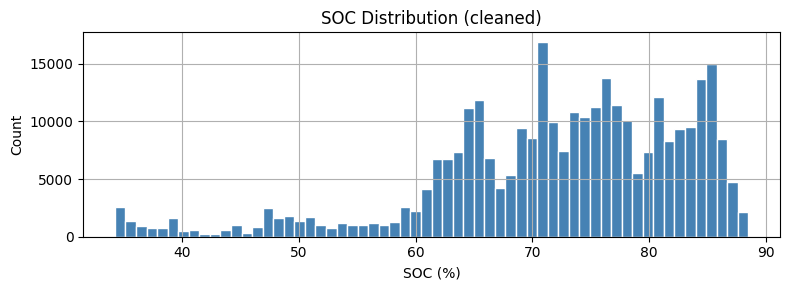

In [8]:
# ============================================================
# CELL 6 — Clean: Drop NaN
# ============================================================
all_cols = feature_cols + [target_col]
df_clean = df[all_cols].dropna().copy()
print('After NaN removal: {} rows'.format(len(df_clean)))



fig, ax = plt.subplots(figsize=(8, 3))
ax.hist(df_clean[target_col], bins=60, color='steelblue', edgecolor='white')
ax.set_title('SOC Distribution (cleaned)')
ax.set_xlabel('SOC (%)'); ax.set_ylabel('Count'); ax.grid(True)
plt.tight_layout(); plt.show()

In [9]:
# ============================================================
# CELL 7 — Normalize
# ============================================================
X_raw = df_clean[feature_cols].values.astype(np.float32)
Y_raw = df_clean[target_col].values.astype(np.float32)

scaler_X = StandardScaler()
X_norm   = scaler_X.fit_transform(X_raw)

Y_mean = float(Y_raw.mean())
Y_std  = float(Y_raw.std())
Y_norm = (Y_raw - Y_mean) / Y_std

print('X shape : {}'.format(X_norm.shape))
print('Y mean  : {:.2f}%   Y std: {:.2f}%'.format(Y_mean, Y_std))

X shape : (314978, 15)
Y mean  : 71.95%   Y std: 11.21%


In [10]:
# ============================================================
# CELL 8 — Sliding Window Sequences
# ============================================================
WINDOW = 60    # Transformer benefits from longer context than BiLSTM

X_seq, Y_seq = [], []
for i in range(len(Y_norm) - WINDOW):
    X_seq.append(X_norm[i : i+WINDOW])
    Y_seq.append(Y_norm[i + WINDOW])

X_seq = np.array(X_seq, dtype=np.float32)   # [N, window, features]
Y_seq = np.array(Y_seq, dtype=np.float32)   # [N]
print('Sequences  X: {}   Y: {}'.format(X_seq.shape, Y_seq.shape))

Sequences  X: (314918, 60, 15)   Y: (314918,)


Train: 251900   Test: 63000


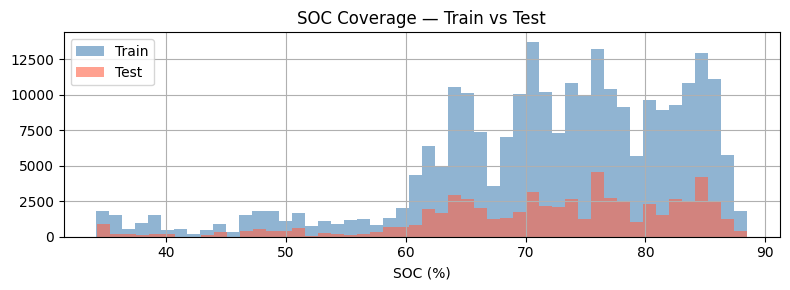

In [11]:
# ============================================================
# CELL 9 — Block-Shuffled Train / Test Split
# ============================================================
BLOCK_SIZE = 100
N          = len(Y_seq)
num_blocks = N // BLOCK_SIZE

rng         = np.random.default_rng(42)
block_order = rng.permutation(num_blocks)

n_train      = int(0.8 * num_blocks)
train_blocks = np.sort(block_order[:n_train])
test_blocks  = np.sort(block_order[n_train:])

def blocks_to_idx(blocks, block_size, max_n):
    idx = np.concatenate([np.arange(b*block_size,
                          min((b+1)*block_size, max_n)) for b in blocks])
    return np.sort(idx)

train_idx = blocks_to_idx(train_blocks, BLOCK_SIZE, N)
test_idx  = blocks_to_idx(test_blocks,  BLOCK_SIZE, N)

X_train, Y_train = X_seq[train_idx], Y_seq[train_idx]
X_test,  Y_test  = X_seq[test_idx],  Y_seq[test_idx]

print('Train: {}   Test: {}'.format(len(Y_train), len(Y_test)))

fig, ax = plt.subplots(figsize=(8, 3))
ax.hist(Y_train*Y_std+Y_mean, bins=50, alpha=0.6, label='Train', color='steelblue')
ax.hist(Y_test *Y_std+Y_mean, bins=50, alpha=0.6, label='Test',  color='tomato')
ax.set_title('SOC Coverage — Train vs Test')
ax.set_xlabel('SOC (%)'); ax.legend(); ax.grid(True)
plt.tight_layout(); plt.show()

In [12]:
# ============================================================
# CELL 10 — PyTorch Dataset & DataLoader
# ============================================================
class SOCDataset(Dataset):
    def __init__(self, X, Y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.Y = torch.tensor(Y, dtype=torch.float32).unsqueeze(1)
    def __len__(self):        return len(self.Y)
    def __getitem__(self, i): return self.X[i], self.Y[i]

BATCH = 512

train_loader = DataLoader(SOCDataset(X_train, Y_train),
                          batch_size=BATCH, shuffle=True,
                          pin_memory=True, num_workers=0)
test_loader  = DataLoader(SOCDataset(X_test, Y_test),
                          batch_size=BATCH, shuffle=False,
                          pin_memory=True, num_workers=0)
print('DataLoaders ready  Batch size: {}'.format(BATCH))

DataLoaders ready  Batch size: 512


In [13]:
# ============================================================
# CELL 11 — Transformer Model Definition
# ============================================================

# --- Positional Encoding ---
class PositionalEncoding(nn.Module):
    """
    Sinusoidal positional encoding injected into the token embeddings.
    Gives the Transformer awareness of sequence position.
    """
    def __init__(self, d_model, max_len=500, dropout=0.1):
        super().__init__()
        self.dropout = nn.Dropout(dropout)

        pe  = torch.zeros(max_len, d_model)           # [max_len, d_model]
        pos = torch.arange(0, max_len).unsqueeze(1).float()   # [max_len, 1]
        div = torch.exp(
            torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model)
        )
        pe[:, 0::2] = torch.sin(pos * div)
        pe[:, 1::2] = torch.cos(pos * div)
        pe = pe.unsqueeze(0)                          # [1, max_len, d_model]
        self.register_buffer('pe', pe)

    def forward(self, x):    # x: [batch, seq, d_model]
        x = x + self.pe[:, :x.size(1), :]
        return self.dropout(x)


# --- Single Transformer Encoder Block ---
class TransformerBlock(nn.Module):
    """
    One encoder block:
      MultiHeadAttention -> Add & Norm -> FeedForward -> Add & Norm
    """
    def __init__(self, d_model, n_heads, d_ff, dropout=0.1):
        super().__init__()
        self.attn    = nn.MultiheadAttention(d_model, n_heads,
                                              dropout=dropout, batch_first=True)
        self.norm1   = nn.LayerNorm(d_model)
        self.norm2   = nn.LayerNorm(d_model)
        self.ff      = nn.Sequential(
            nn.Linear(d_model, d_ff),
            nn.GELU(),                  # GELU works better than ReLU in Transformers
            nn.Dropout(dropout),
            nn.Linear(d_ff, d_model),
            nn.Dropout(dropout)
        )

    def forward(self, x):              # x: [batch, seq, d_model]
        # Multi-head self-attention + residual
        attn_out, _ = self.attn(x, x, x)
        x = self.norm1(x + attn_out)
        # Feed-forward + residual
        x = self.norm2(x + self.ff(x))
        return x


# --- Full Transformer SOC Model ---
class TransformerSOC(nn.Module):
    """
    Input projection -> Positional Encoding -> N x TransformerBlock
    -> Mean pooling -> FC regression head
    """
    def __init__(self, input_size, d_model=128, n_heads=8,
                 d_ff=256, n_layers=4, dropout=0.1):
        super().__init__()

        assert d_model % n_heads == 0, 'd_model must be divisible by n_heads'

        # Project raw features to d_model dimensions
        self.input_proj = nn.Sequential(
            nn.Linear(input_size, d_model),
            nn.LayerNorm(d_model)
        )

        # Positional encoding
        self.pos_enc = PositionalEncoding(d_model, dropout=dropout)

        # Stack of Transformer encoder blocks
        self.blocks = nn.ModuleList([
            TransformerBlock(d_model, n_heads, d_ff, dropout)
            for _ in range(n_layers)
        ])

        # Regression head
        self.head = nn.Sequential(
            nn.Linear(d_model, d_model // 2),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(d_model // 2, d_model // 4),
            nn.GELU(),
            nn.Linear(d_model // 4, 1)
        )

    def forward(self, x):              # x: [batch, seq, features]
        x = self.input_proj(x)         # [batch, seq, d_model]
        x = self.pos_enc(x)            # inject position info
        for block in self.blocks:
            x = block(x)               # self-attention + FFN
        x = x.mean(dim=1)             # mean pool over time -> [batch, d_model]
        return self.head(x)            # -> [batch, 1]


num_features = X_train.shape[2]   # 15

model = TransformerSOC(
    input_size = num_features,
    d_model    = 128,    # embedding dimension
    n_heads    = 8,      # attention heads (128 / 8 = 16 per head)
    d_ff       = 256,    # feed-forward hidden dim
    n_layers   = 4,      # number of encoder blocks
    dropout    = 0.1
).to(device)

total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print('Model parameters: {:,}'.format(total_params))
print(model)

Model parameters: 542,593
TransformerSOC(
  (input_proj): Sequential(
    (0): Linear(in_features=15, out_features=128, bias=True)
    (1): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
  )
  (pos_enc): PositionalEncoding(
    (dropout): Dropout(p=0.1, inplace=False)
  )
  (blocks): ModuleList(
    (0-3): 4 x TransformerBlock(
      (attn): MultiheadAttention(
        (out_proj): NonDynamicallyQuantizableLinear(in_features=128, out_features=128, bias=True)
      )
      (norm1): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
      (norm2): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
      (ff): Sequential(
        (0): Linear(in_features=128, out_features=256, bias=True)
        (1): GELU(approximate='none')
        (2): Dropout(p=0.1, inplace=False)
        (3): Linear(in_features=256, out_features=128, bias=True)
        (4): Dropout(p=0.1, inplace=False)
      )
    )
  )
  (head): Sequential(
    (0): Linear(in_features=128, out_features=64, bias=True)
    

In [14]:
# ============================================================
# CELL 12 — Training Setup
# ============================================================
EPOCHS   = 60
LR       = 1e-4    # Transformers prefer lower LR than LSTMs
L2       = 1e-4
PATIENCE = 12

criterion = nn.MSELoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=L2)

# Warmup + cosine decay: best practice for Transformers
def lr_lambda(epoch):
    warmup_epochs = 5
    if epoch < warmup_epochs:
        return float(epoch + 1) / float(warmup_epochs)
    progress = float(epoch - warmup_epochs) / float(max(1, EPOCHS - warmup_epochs))
    return max(0.05, 0.5 * (1.0 + math.cos(math.pi * progress)))

scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)

print('Optimizer : AdamW   LR={}   L2={}'.format(LR, L2))
print('Scheduler : Warmup ({} epochs) + Cosine Decay'.format(5))
print('Epochs    : {}   Patience: {}'.format(EPOCHS, PATIENCE))

Optimizer : AdamW   LR=0.0001   L2=0.0001
Scheduler : Warmup (5 epochs) + Cosine Decay
Epochs    : 60   Patience: 12


In [15]:
# ============================================================
# CELL 13 — Training Loop
# ============================================================
import time
import copy

train_losses, val_losses, lr_history = [], [], []
best_val_loss    = float('inf')
best_model_wts   = copy.deepcopy(model.state_dict())
patience_counter = 0
epoch_times      = []

header = '{:>6}  {:>12}  {:>10}  {:>10}  {:>10}  {:>8}'.format(
         'Epoch', 'Train Loss', 'Val Loss', 'LR', 'Patience', 'Time(s)')
print(header)
print('-' * 72)

for epoch in range(1, EPOCHS + 1):
    t0 = time.time()

    # ---- Train ----
    model.train()
    running_loss = 0.0
    for Xb, Yb in train_loader:
        Xb = Xb.to(device, non_blocking=True)
        Yb = Yb.to(device, non_blocking=True)
        optimizer.zero_grad(set_to_none=True)
        loss = criterion(model(Xb), Yb)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        running_loss += loss.item() * Xb.size(0)

    train_loss = running_loss / len(train_loader.dataset)

    # ---- Validate ----
    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for Xb, Yb in test_loader:
            Xb = Xb.to(device, non_blocking=True)
            Yb = Yb.to(device, non_blocking=True)
            val_loss += criterion(model(Xb), Yb).item() * Xb.size(0)
    val_loss /= len(test_loader.dataset)

    elapsed = time.time() - t0
    epoch_times.append(elapsed)
    train_losses.append(train_loss)
    val_losses.append(val_loss)

    scheduler.step()
    current_lr = optimizer.param_groups[0]['lr']
    lr_history.append(current_lr)

    # Early stopping
    if val_loss < best_val_loss:
        best_val_loss    = val_loss
        best_model_wts   = copy.deepcopy(model.state_dict())
        patience_counter = 0
        tag = 'BEST'
    else:
        patience_counter += 1
        tag = ''

    if epoch % 5 == 0 or epoch == 1:
        print('{:>6}  {:>12.6f}  {:>10.6f}  {:>10.2e}  {:>4}/{:<4}  {:>7.1f}s  {}'.format(
              epoch, train_loss, val_loss, current_lr,
              patience_counter, PATIENCE, elapsed, tag))

    if patience_counter >= PATIENCE:
        print('\nEarly stopping triggered at epoch {} '.format(epoch))
        break

model.load_state_dict(best_model_wts)
print('\nBest Val Loss : {:.6f}'.format(best_val_loss))
print('Avg Epoch Time: {:.1f}s'.format(np.mean(epoch_times)))

 Epoch    Train Loss    Val Loss          LR    Patience   Time(s)
------------------------------------------------------------------------
     1      0.285637    0.049526    4.00e-05     0/12       52.8s  BEST
     5      0.006266    0.002686    1.00e-04     0/12       54.2s  BEST
    10      0.003118    0.001953    9.80e-05     2/12       54.2s  
    15      0.002105    0.001679    9.21e-05     4/12       54.1s  
    20      0.001591    0.003029    8.27e-05     9/12       54.1s  

Early stopping triggered at epoch 23 

Best Val Loss : 0.001510
Avg Epoch Time: 54.0s


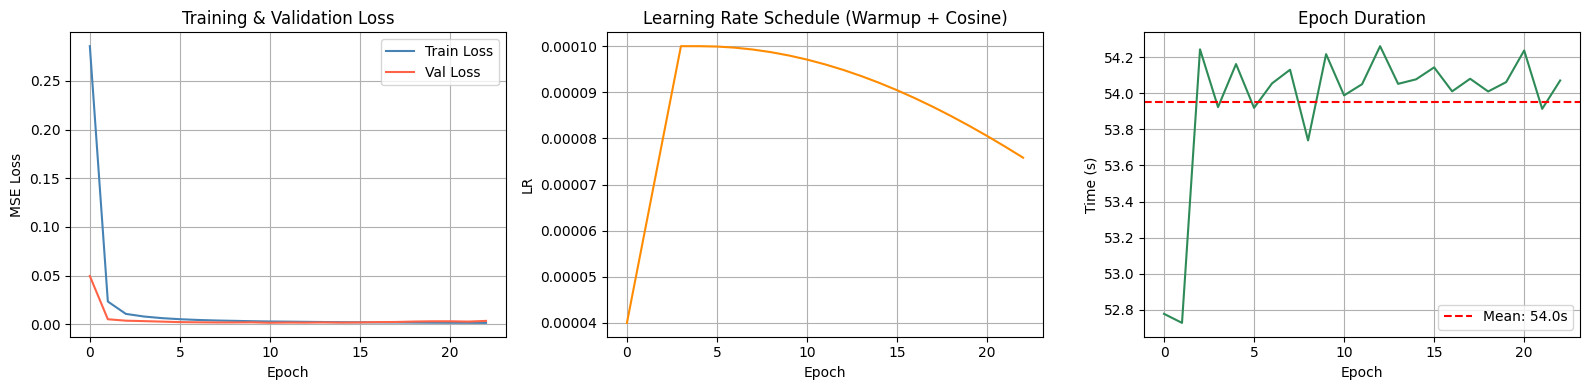

In [17]:
# ============================================================
# CELL 14 — Loss & LR Curves
# ============================================================
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

ax = axes[0]
ax.plot(train_losses, label='Train Loss', color='steelblue', linewidth=1.5)
ax.plot(val_losses,   label='Val Loss',   color='tomato',    linewidth=1.5)
ax.set_title('Training & Validation Loss')
ax.set_xlabel('Epoch'); ax.set_ylabel('MSE Loss')
ax.legend(); ax.grid(True)

ax = axes[1]
ax.plot(lr_history, color='darkorange', linewidth=1.5)
ax.set_title('Learning Rate Schedule (Warmup + Cosine)')
ax.set_xlabel('Epoch'); ax.set_ylabel('LR')
ax.grid(True)

ax = axes[2]
ax.plot(epoch_times, color='seagreen', linewidth=1.5)
ax.axhline(np.mean(epoch_times), color='red', linestyle='--',
           label='Mean: {:.1f}s'.format(np.mean(epoch_times)))
ax.set_title('Epoch Duration')
ax.set_xlabel('Epoch'); ax.set_ylabel('Time (s)')
ax.legend(); ax.grid(True)

plt.tight_layout(); plt.savefig('loss_curve.png', dpi=150); plt.show()

In [18]:
# ============================================================
# CELL 15 — Predict & Denormalize
# ============================================================
model.eval()
all_preds, all_true = [], []

with torch.no_grad():
    for Xb, Yb in test_loader:
        Xb = Xb.to(device, non_blocking=True)
        all_preds.extend(model(Xb).cpu().numpy().flatten())
        all_true.extend(Yb.numpy().flatten())

Y_pred = np.array(all_preds) * Y_std + Y_mean
Y_true = np.array(all_true)  * Y_std + Y_mean

print('True  range: [{:.1f}, {:.1f}]'.format(Y_true.min(), Y_true.max()))
print('Pred  range: [{:.1f}, {:.1f}]'.format(Y_pred.min(), Y_pred.max()))

True  range: [34.3, 88.5]
Pred  range: [34.0, 88.4]


In [19]:
# ============================================================
# CELL 16 — Metrics
# ============================================================
RMSE = math.sqrt(mean_squared_error(Y_true, Y_pred))
MAE  = mean_absolute_error(Y_true, Y_pred)
R2   = r2_score(Y_true, Y_pred)
MAPE = np.mean(np.abs((Y_true - Y_pred) / (np.abs(Y_true) + 1e-8))) * 100

print('=' * 44)
print('     Transformer SOC PERFORMANCE')
print('=' * 44)
print('  RMSE = {:.4f} %'.format(RMSE))
print('  MAE  = {:.4f} %'.format(MAE))
print('  MAPE = {:.2f} %'.format(MAPE))
print('  R2   = {:.4f}'.format(R2))
print('=' * 44)

     Transformer SOC PERFORMANCE
  RMSE = 0.4357 %
  MAE  = 0.3204 %
  MAPE = 0.46 %
  R2   = 0.9985


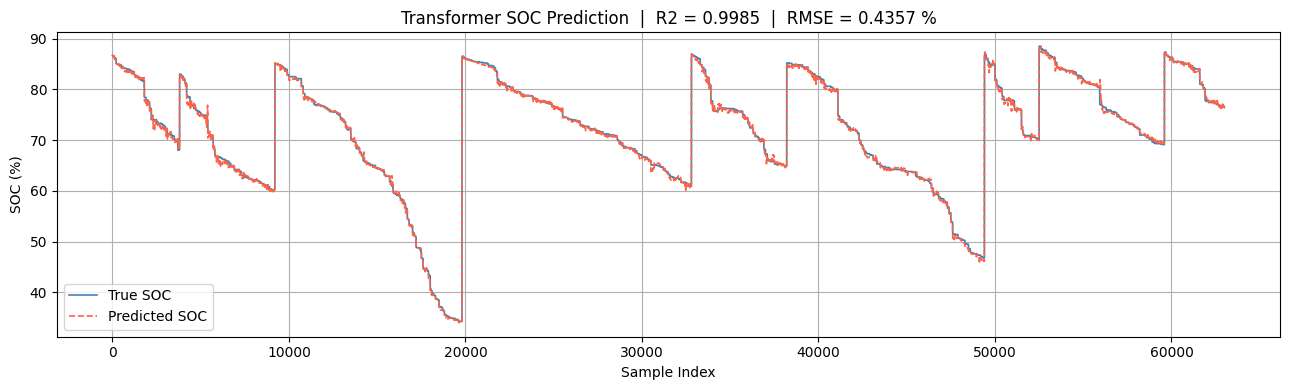

In [22]:
# ============================================================
# CELL 17 — Plot 1: Prediction vs Actual
# ============================================================
fig, ax = plt.subplots(figsize=(13, 4))
ax.plot(Y_true, color='steelblue', linewidth=1.2, label='True SOC')
ax.plot(Y_pred, color='tomato',    linewidth=1.2, linestyle='--', label='Predicted SOC')
ax.set_title('Transformer SOC Prediction  |  R2 = {:.4f}  |  RMSE = {:.4f} %'.format(R2, RMSE))
ax.set_xlabel('Sample Index'); ax.set_ylabel('SOC (%)')
ax.legend(); ax.grid(True)
plt.tight_layout(); plt.savefig('soc_prediction.png', dpi=150); plt.show()

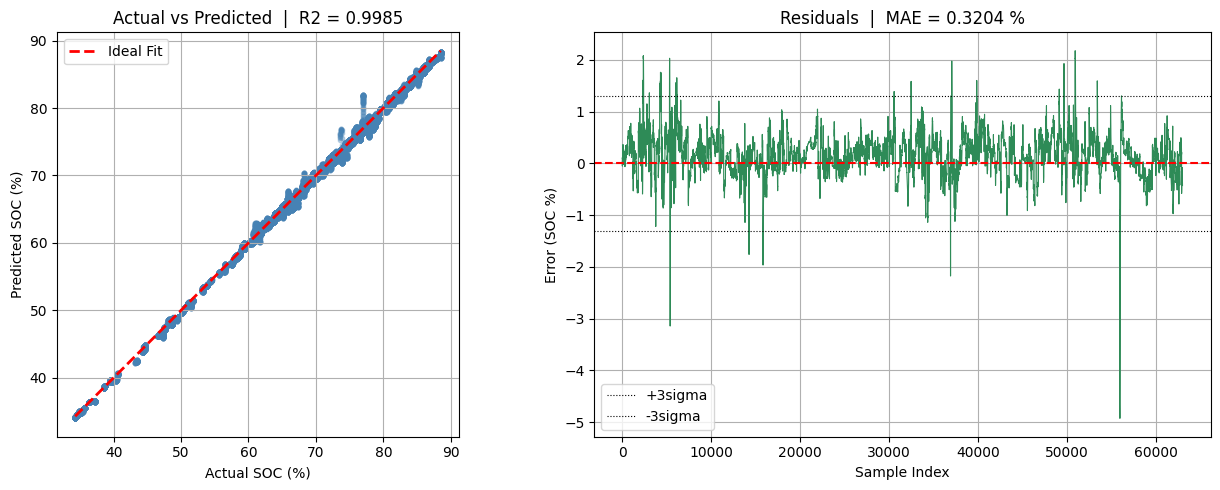

In [23]:
# ============================================================
# CELL 18 — Plot 2: Scatter  &  Plot 3: Residuals
# ============================================================
residuals = Y_true - Y_pred

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ax = axes[0]
ax.scatter(Y_true, Y_pred, alpha=0.3, s=10, color='steelblue')
ref = [Y_true.min(), Y_true.max()]
ax.plot(ref, ref, 'r--', linewidth=2, label='Ideal Fit')
ax.set_title('Actual vs Predicted  |  R2 = {:.4f}'.format(R2))
ax.set_xlabel('Actual SOC (%)'); ax.set_ylabel('Predicted SOC (%)')
ax.legend(); ax.grid(True); ax.set_aspect('equal', 'box')

ax = axes[1]
ax.plot(residuals, color='seagreen', linewidth=0.8)
ax.axhline(0,       color='red',   linewidth=1.5, linestyle='--')
ax.axhline( 3*RMSE, color='black', linewidth=0.8, linestyle=':', label='+3sigma')
ax.axhline(-3*RMSE, color='black', linewidth=0.8, linestyle=':', label='-3sigma')
ax.set_title('Residuals  |  MAE = {:.4f} %'.format(MAE))
ax.set_xlabel('Sample Index'); ax.set_ylabel('Error (SOC %)')
ax.legend(); ax.grid(True)

plt.tight_layout(); plt.savefig('residuals.png', dpi=150); plt.show()

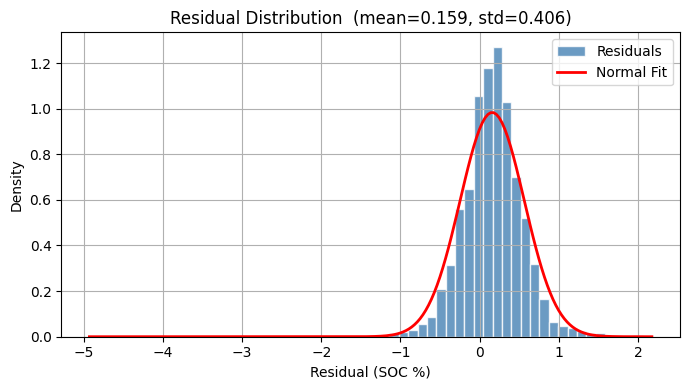

In [24]:
# ============================================================
# CELL 19 — Plot 4: Residual Distribution
# ============================================================
fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(residuals, bins=60, density=True, color='steelblue',
        edgecolor='white', alpha=0.8, label='Residuals')
x_fit   = np.linspace(residuals.min(), residuals.max(), 200)
mu_r, s = stats.norm.fit(residuals)
ax.plot(x_fit, stats.norm.pdf(x_fit, mu_r, s), 'r-', linewidth=2, label='Normal Fit')
ax.set_title('Residual Distribution  (mean={:.3f}, std={:.3f})'.format(mu_r, s))
ax.set_xlabel('Residual (SOC %)'); ax.set_ylabel('Density')
ax.legend(); ax.grid(True)
plt.tight_layout(); plt.savefig('residual_dist.png', dpi=150); plt.show()

TypeError: Invalid shape (60,) for image data

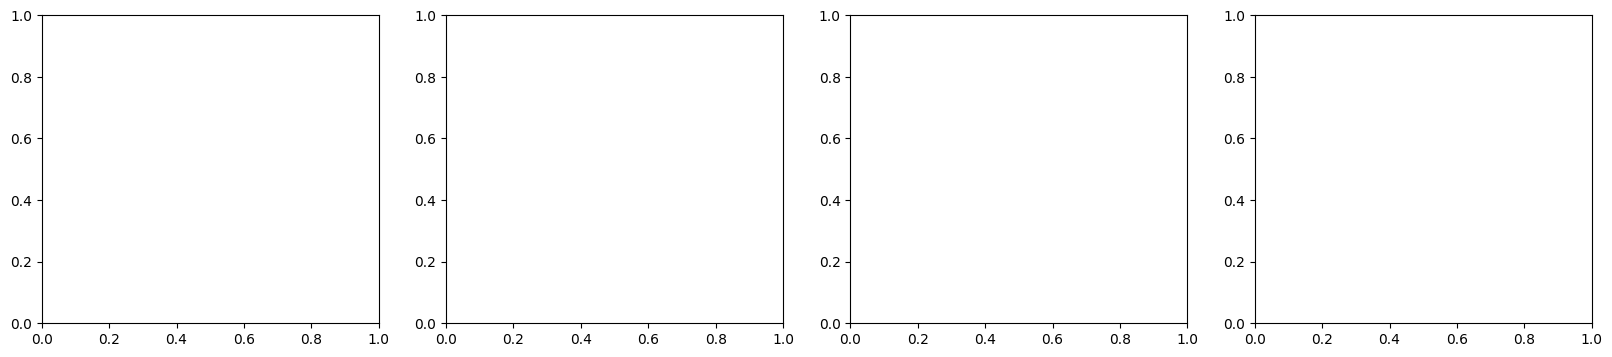

In [26]:
# ============================================================
# CELL 20 — Attention Weight Visualization
#   Shows what timesteps the Transformer attends to most
#   for a random test sample (unique to Transformer models)
# ============================================================
model.eval()

# Hook to capture attention weights from all blocks
attn_weights = []
hooks = []

def make_hook(i):
    def hook_fn(module, input, output):
        # output = (attn_output, attn_weights)
        if output[1] is not None:
            attn_weights.append(output[1].detach().cpu())
    return hook_fn

for i, block in enumerate(model.blocks):
    hooks.append(block.attn.register_forward_hook(make_hook(i)))

# Forward pass on one sample
sample_idx = 0
x_sample   = torch.tensor(X_test[sample_idx:sample_idx+1], dtype=torch.float32).to(device)

with torch.no_grad():
    _ = model(x_sample)

for h in hooks:
    h.remove()

if attn_weights:
    fig, axes = plt.subplots(1, len(attn_weights), figsize=(5*len(attn_weights), 4))
    if len(attn_weights) == 1:
        axes = [axes]
    for i, w in enumerate(attn_weights):
        # w shape: [batch, heads, seq, seq] — average over heads
        avg_w = w[0].mean(dim=0).numpy()   # [seq, seq]
        im = axes[i].imshow(avg_w, cmap='viridis', aspect='auto')
        axes[i].set_title('Block {} Attention'.format(i+1))
        axes[i].set_xlabel('Key timestep')
        axes[i].set_ylabel('Query timestep')
        plt.colorbar(im, ax=axes[i])
    plt.suptitle('Self-Attention Weights (averaged over heads)', y=1.02)
    plt.tight_layout()
    plt.savefig('attention_maps.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('Attention maps saved ✅')
else:
    print('No attention weights captured (need_weights=False by default in some PyTorch versions)')

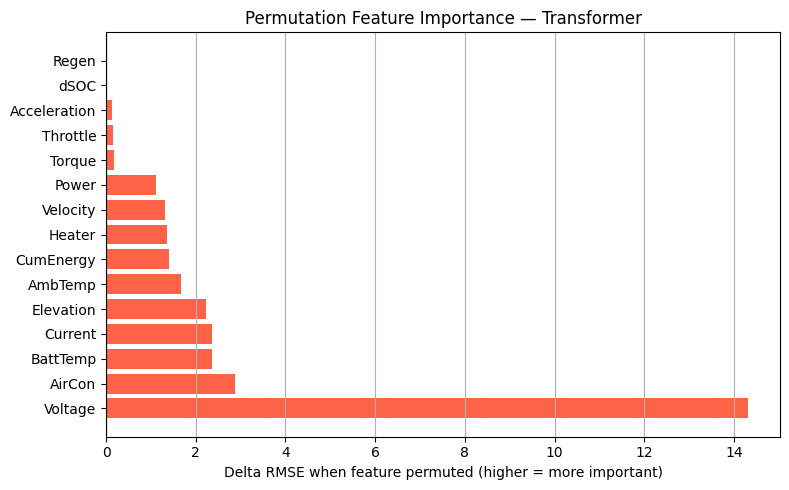

In [27]:
# ============================================================
# CELL 21 — Feature Importance (Permutation)
# ============================================================
feature_names = [
    'Velocity', 'Elevation', 'Throttle', 'Torque', 'Acceleration', 'Regen',
    'Voltage',  'Current',   'BattTemp', 'AmbTemp','AirCon',       'Heater',
    'Power',    'dSOC',      'CumEnergy'
]

X_test_t  = torch.tensor(X_test, dtype=torch.float32)
perm_rmse = []

model.eval()
with torch.no_grad():
    for f in range(num_features):
        X_perm = X_test_t.clone()
        idx    = torch.randperm(X_perm.shape[0])
        X_perm[:, :, f] = X_perm[idx, :, f]

        preds = []
        for i in range(0, len(X_perm), BATCH):
            preds.extend(model(X_perm[i:i+BATCH].to(device)).cpu().numpy().flatten())

        Yp = np.array(preds) * Y_std + Y_mean
        perm_rmse.append(math.sqrt(mean_squared_error(Y_true, Yp)))

importance = np.array(perm_rmse) - RMSE
sort_idx   = np.argsort(importance)[::-1]

fig, ax = plt.subplots(figsize=(8, 5))
colors = ['tomato' if v > 0 else 'steelblue' for v in importance[sort_idx]]
ax.barh([feature_names[i] for i in sort_idx], importance[sort_idx], color=colors)
ax.set_xlabel('Delta RMSE when feature permuted (higher = more important)')
ax.set_title('Permutation Feature Importance — Transformer')
ax.axvline(0, color='black', linewidth=0.8)
ax.grid(True, axis='x')
plt.tight_layout(); plt.savefig('feature_importance.png', dpi=150); plt.show()

In [ ]:
# ============================================================
# CELL 22 — Save Model & Download All Outputs
# ============================================================
torch.save({
    'model_state_dict': model.state_dict(),
    'model_config': {
        'input_size': num_features,
        'd_model':    128,
        'n_heads':    8,
        'd_ff':       256,
        'n_layers':   4,
        'dropout':    0.1
    },
    'scaler_X':      scaler_X,
    'Y_mean':        Y_mean,
    'Y_std':         Y_std,
    'window_size':   WINDOW,
    'feature_names': feature_names,
    'metrics': {
        'RMSE': float(RMSE),
        'MAE':  float(MAE),
        'R2':   float(R2),
        'MAPE': float(MAPE)
    }
}, 'transformer_soc_model.pt')

print('Model saved ')
print('Final -> R2: {:.4f}  RMSE: {:.4f}%  MAE: {:.4f}%  MAPE: {:.2f}%'.format(
      R2, RMSE, MAE, MAPE))

from google.colab import files
outputs = ['transformer_soc_model.pt', 'soc_prediction.png', 'residuals.png',
           'residual_dist.png', 'feature_importance.png', 'loss_curve.png']
try:
    outputs.append('attention_maps.png')
except:
    pass

for fname in outputs:
    try:
        files.download(fname)
        print('Downloaded: {}'.format(fname))
    except Exception as e:
        print('Skipped: {}  ({})'.format(fname, e))